In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt


# Read excel file
df1 = pd.read_excel("/home/sandeep/Desktop/Musharaff/TEK00010.xls")
df2 = pd.read_excel("/home/sandeep/Desktop/Musharaff/TEK00011.xls")



In [9]:

df1.head()

,TIME,CH1
0,-1.000000e-06,-0.1040
1,-9.990000e-07,-0.1024
2,-9.980000e-07,-0.1024
3,-9.970000e-07,-0.1016
4,-9.960000e-07,-0.1024


In [10]:
df2.head()

,TIME,CH1
0,-1.000000e-06,-0.1112
1,-9.990000e-07,-0.1128
2,-9.980000e-07,-0.1128
3,-9.970000e-07,-0.1128
4,-9.960000e-07,-0.1128


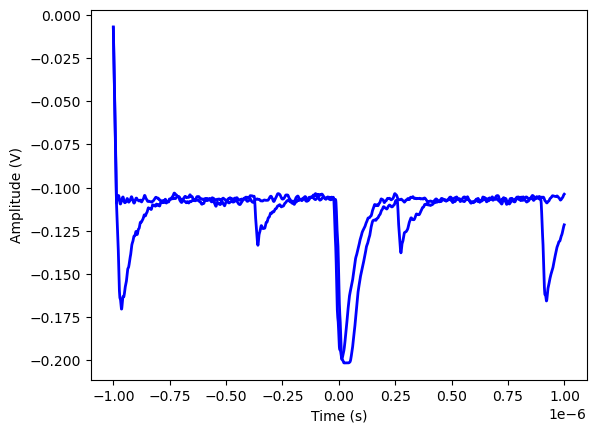

In [ ]:


time1 = df1["TIME"].to_numpy()
channel1 = df1["CH1"].to_numpy()

channel2 = df2["CH1"].to_numpy()

from scipy.signal import lfilter

n = 15  # the larger n is, the smoother curve will be
b = [1.0 / n] * n
a = 1
yy1 = lfilter(b, a, channel1)
yy2 = lfilter(b, a, channel2)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.plot(time1, yy1, linewidth=2, linestyle="-", c="b")  # smooth by filter
plt.plot(time1, yy2, linewidth=2, linestyle="-", c="b")  # smooth by filter
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt

import os
for file in os.listdir("/home/sandeep/Desktop/Musharaff/w_ND_LED/"):
    if file.endswith(".csv"):
        # df1 = pd.read_csv(file, skiprows=20)
        # df1.head()
        df1= pd.read_csv(os.path.join("/home/sandeep/Desktop/Musharaff/w_ND_LED/", file))
        df1.head()
# df1 = pd.read_csv("/home/sandeep/Desktop/Musharaff/w_ND_LED/SaveOnEvent_s1_ch1_20260314173748600.csv", skiprows=12)
# df1.head()


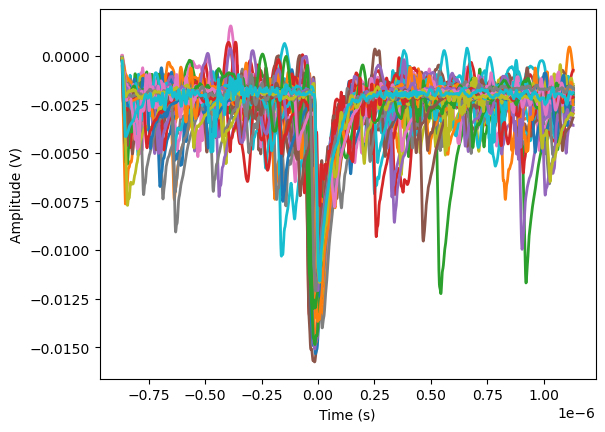

In [14]:
import os
from scipy.signal import lfilter

for file in os.listdir("/home/sandeep/Desktop/Musharaff/w_ND_LED/"):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join("/home/sandeep/Desktop/Musharaff/w_ND_LED/", file), skiprows=10)
        time = df["TIME"].to_numpy()
        channel = df["S1_CH1"].to_numpy()
        n = 15
        b = [1.0 / n] * n
        a = 1
        yy = lfilter(b, a, channel)
        plt.plot(time, yy, linewidth=2, linestyle="-", label=file)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
# plt.legend()
plt.show()

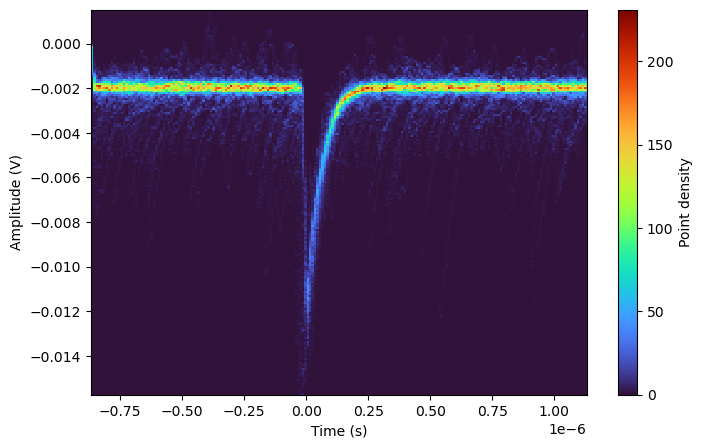

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

all_time = []
all_amp = []

for file in os.listdir("/home/sandeep/Desktop/Musharaff/w_ND_LED/"):
    if file.endswith(".csv"):

        df = pd.read_csv(
            os.path.join("/home/sandeep/Desktop/Musharaff/w_ND_LED/", file),
            skiprows=10
        )

        time = df["TIME"].to_numpy()
        channel = df["S1_CH1"].to_numpy()

        n = 15
        b = [1.0/n]*n
        a = 1
        yy = lfilter(b, a, channel)

        all_time.append(time)
        all_amp.append(yy)

all_time = np.concatenate(all_time)
all_amp = np.concatenate(all_amp)

plt.figure(figsize=(8,5))

plt.hist2d(
    all_time,
    all_amp,
    bins=200,
    cmap="turbo"   # nice oscilloscope-like colors
)

plt.colorbar(label="Point density")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.show()

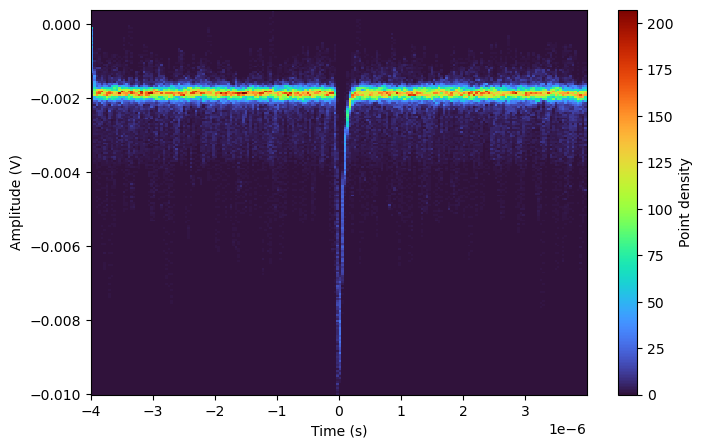

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

all_time = []
all_amp = []

for file in os.listdir("/home/sandeep/Desktop/Musharaff/wo_NDUV/"):
    if file.endswith(".csv"):

        df = pd.read_csv(
            os.path.join("/home/sandeep/Desktop/Musharaff/wo_NDUV/", file),
            skiprows=11
        )

        time = df["TIME"].to_numpy()
        channel = df["S1_CH1"].to_numpy()

        n = 15
        b = [1.0/n]*n
        a = 1
        yy = lfilter(b, a, channel)

        all_time.append(time)
        all_amp.append(yy)

all_time = np.concatenate(all_time)
all_amp = np.concatenate(all_amp)

plt.figure(figsize=(8,5))

plt.hist2d(
    all_time,
    all_amp,
    bins=200,
    cmap="turbo"   # nice oscilloscope-like colors
)

plt.colorbar(label="Point density")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.show()